#📌 Extracción

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [9]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

df = pd.concat([df[['customerID','Churn']], customer, phone, internet, account], axis=1)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#📊 Carga y análisis

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267

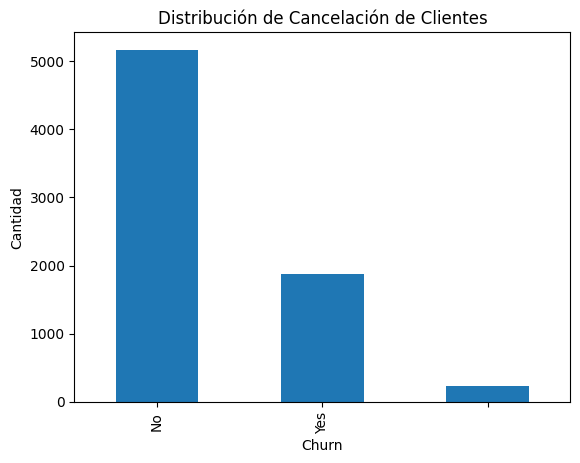

<Figure size 640x480 with 0 Axes>

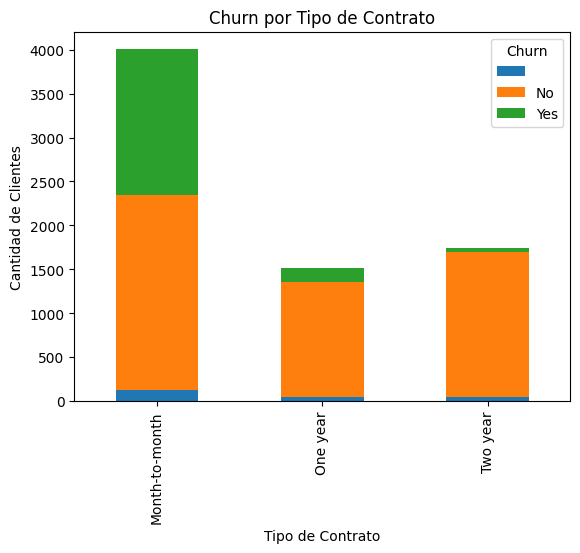

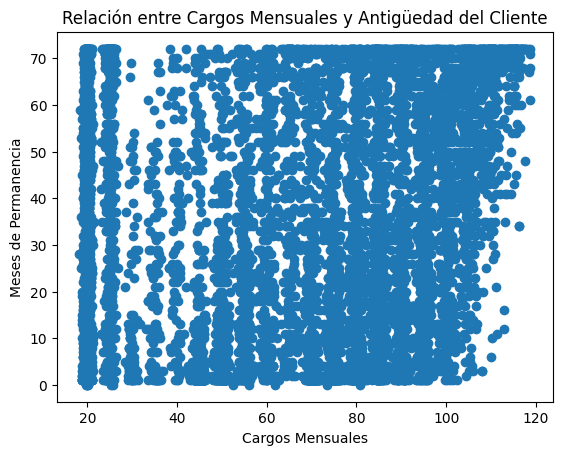

In [10]:
# ==============================
# CARGA Y ANÁLISIS EXPLORATORIO
# ==============================

import matplotlib.pyplot as plt

# 1. Información general del dataset
print("INFORMACIÓN GENERAL")
print(df.info())

print("\nVALORES NULOS")
print(df.isnull().sum())

print("\nESTADÍSTICAS DESCRIPTIVAS")
print(df.describe())

# 2. Distribución de Churn
plt.figure()
df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de Cancelación de Clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad")
plt.show()

# 3. Churn por tipo de contrato
plt.figure()
contrato_churn = df.groupby(["Contract","Churn"]).size().unstack()
contrato_churn.plot(kind="bar", stacked=True)
plt.title("Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Cantidad de Clientes")
plt.show()

# 4. Cargos mensuales vs permanencia
plt.figure()
plt.scatter(df["Charges.Monthly"], df["tenure"])
plt.title("Relación entre Cargos Mensuales y Antigüedad del Cliente")
plt.xlabel("Cargos Mensuales")
plt.ylabel("Meses de Permanencia")
plt.show()

#📄Informe final


Introducción

En este proyecto se realizó un análisis de datos sobre los clientes de la empresa TelecomX con el objetivo de entender mejor los factores que pueden influir en la cancelación del servicio (Churn).

Para ello se trabajó con un dataset en formato JSON que fue procesado y analizado utilizando Python y librerías de análisis de datos.

Preparación de los datos

Primero se realizó la extracción de los datos desde el archivo proporcionado. Luego se transformaron las estructuras anidadas del JSON para poder trabajar con ellas en formato tabular dentro de un DataFrame.

Durante esta etapa también se revisaron los tipos de datos, valores faltantes y la estructura general del dataset para asegurar que la información estuviera lista para el análisis.

Análisis de los datos

Durante el análisis exploratorio se observaron algunos patrones interesantes.

Uno de los puntos más claros es que los clientes con contratos mes a mes presentan una mayor tendencia a cancelar el servicio en comparación con aquellos que tienen contratos de mayor duración.

También se pudo observar que los clientes con cargos mensuales más altos presentan una mayor probabilidad de cancelar el servicio.

Otro factor relevante es el tiempo que llevan como clientes. Aquellos que llevan menos tiempo con la empresa muestran una mayor tasa de cancelación, lo que sugiere que los primeros meses son muy importantes para la retención de clientes.

Conclusiones

A partir del análisis realizado se pueden destacar algunos factores que parecen estar relacionados con el churn:

Los contratos mensuales presentan mayor tasa de cancelación.

Los clientes con cargos mensuales más altos tienden a cancelar más.

Los clientes nuevos tienen mayor probabilidad de abandonar el servicio.

Esto puede ayudar a la empresa a identificar clientes con mayor riesgo de cancelación.

Recomendaciones

Como posibles acciones para mejorar la retención de clientes se podrían considerar:

Promover contratos de mayor duración.

Revisar la estructura de precios o beneficios ofrecidos.

Implementar estrategias de fidelización para clientes nuevos.

Conclusión final

El análisis exploratorio permitió identificar algunos patrones importantes relacionados con la cancelación de clientes. Aunque se trata de un análisis inicial, los resultados muestran cómo el uso de datos puede ayudar a comprender mejor el comportamiento de los clientes y apoyar la toma de decisiones.
*   Elemento de lista
*   Elemento de lista

